In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
cm_number = 10
cm = plt.cm.get_cmap("tab10")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset, zoomed_inset_axes
mpl.rc('font', family='Arial')
mpl.rc('font',size = 6)
mpl.rc('mathtext',fontset = 'stix')
mpl.rc('xtick', labelsize=4)
mpl.rc('ytick', labelsize=4)
# mpl.rc('xtick', labelsize=4)
# mpl.rc('ytick', labelsize=4)
mpl.rc('axes', labelsize=6)
mpl.rc('axes', labelpad=1)
mpl.rc('axes', titlesize=6)
mpl.rc('axes', linewidth=0.5)
figsavepath = "../../Elements/Numerical"

C:\Users\TengMa\AppData\Local\Temp\ipykernel_31860\3826260563.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap("tab10")


In [434]:
# Visu external forcing effects

Fs = 100
T = 1000
t = np.linspace(0,T,T*Fs)
omega0 = 2

Amplitude_F = 0.05 # Forcing Amplitude
damping = 1e-2
cubic = 1e-4
quadratic = 1e-2
def Quadratic(x,t, Amplitude_F):
    dxdt = [x[1], -omega0**2*x[0]-damping*x[1]-quadratic*x[1]**2-cubic*x[0]**3+Amplitude_F*np.cos(Omega*t)]
    return dxdt
x0 = [2,0]
Omega = 1.999

# data = x[:,0]
Amplitude_Fs = np.linspace(0,1e0,101)

datas = np.zeros([len(Amplitude_Fs), T*Fs])
Fpeaks = np.zeros([len(Amplitude_Fs),3])
for i in range(len(Amplitude_Fs)):
    x = odeint(Quadratic, x0, t, args = (Amplitude_Fs[i],))
    datas[i] = x[:,0]
    N = len(datas[i])
    yf = fft(datas[i])
    xf = fftfreq(N, (t[-1]-t[0])/len(t))[:N//2]
    Fpeaks[i,0] = 2.0/N * np.abs(yf[:N//2][xf*2*np.pi<0.2]).max()
    Fpeaks[i,1] = 2.0/N * np.abs(yf[:N//2][(xf*2*np.pi<2.2) & (xf*2*np.pi>1.8)]).max()
    Fpeaks[i,2] = 2.0/N * np.abs(yf[:N//2][(xf*2*np.pi<4.2) & (xf*2*np.pi>3.8)]).max()


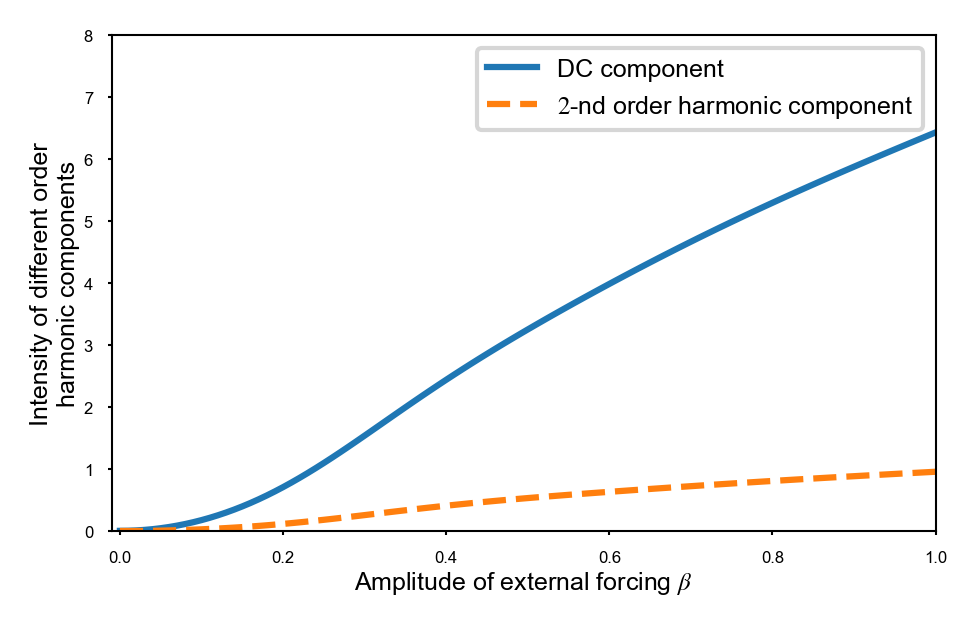

In [452]:
fig, ax = plt.subplots(figsize = (9/2.54,9*0.618/2.54),dpi = 300)
ax.plot(Amplitude_Fs[:], Fpeaks[:,0],label = 'DC component')
ax.plot(Amplitude_Fs[:], Fpeaks[:,2],label = '$2$-nd order harmonic component',ls = '--')
ax
ax.set_xlim(-.01,1)
ax.set_ylim(0,8)
ax.set_xlabel(r'Amplitude of external forcing $\beta$')
ax.set_ylabel('Intensity of different order\nharmonic components')
# ax.set_yscale('log')
# ax.set_xscale('log')
ax.tick_params(direction='out',width = 0.5,length = 1)
ax.legend(fontsize = 6)
plt.savefig("%s/multipleHC.pdf"%figsavepath,dpi = 300,transparent = True,bbox_inches="tight")

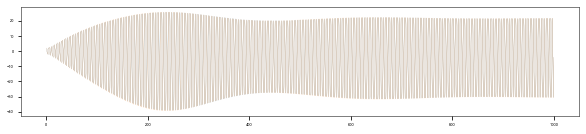

In [439]:
plt.subplots(figsize = (10,2))
plt.plot(t,datas[-2],lw = 0.1)
plt.plot(t, datas[-1], lw = 0.1)

In [236]:

Fs = 100
T = 1000
t = np.linspace(0,T,T*Fs)
omega0 = 2

Amplitude_F = 0.5# Forcing Amplitude
damping = 1e-2
cubic = 1e-4
quadratic = 1e-2

def Quadratic(x,t, Omega):
    dxdt = [x[1], -omega0**2*x[0]-damping*x[1]-quadratic*x[0]**2-cubic*x[0]**3+Amplitude_F*np.cos(Omega*t)]
    return dxdt
x0 = [0,0]
Omega = 1.999
F = np.cos(Omega*t)
x = odeint(Quadratic, x0, t, args = (Omega,))
data = x[:,0]

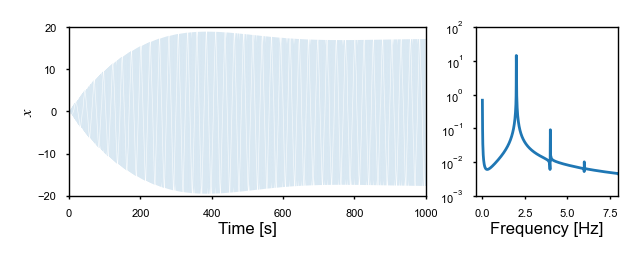

In [237]:
# Visu data
fig, axes = plt.subplots(1,2,figsize = (9/2.54,9*0.618/2/2.54),  gridspec_kw={'width_ratios': [2.5, 1]},dpi = 200)
ax = axes[0]
# axins = inset_axes(ax, width="80%", height="60%", bbox_to_anchor=(0.165, 0.75, 0.5, 0.5),  # 右侧中部
#                    bbox_transform=ax.figure.transFigure, loc='center') 
ax.plot(t,data,lw = 0.03)
ax.set_ylim(-20,20)
x1,x2 = 100*Fs,200*Fs
# axins.plot(t,data,lw = 0.2)
# axins.set_xlim(t[x1],t[x2])
# axins.set_ylim(-8,8)
ax.set_xlim(0,1000)
ax.tick_params(direction='out',width = 0.5,length = 1)
ax.set_xlabel("Time [s]")
ax.set_ylabel("$x$")

N = len(data)
yf = fft(data)
xf = fftfreq(N, (t[-1]-t[0])/len(t))[:N//2]
ax = axes[1]
ax.plot(xf*2*np.pi, 2.0/N * np.abs(yf[0:N//2]), lw = 1)
ax.set_xlim(-.4,8)
ax.tick_params(direction='out',width = 0.5,length = 1)

ax.set_yscale('log')
# ax.set_yticklabels([r'$\Gamma$','b','c','d'])
# ax.set_yticks([1e-2,1e-1,1e0,1e1])

ax.set_xlabel("Frequency [Hz]")
ax.minorticks_off()
ax.set_ylim(1e-3,1e2)
plt.savefig("%s/generatedata.pdf"%figsavepath,dpi = 300,transparent = True,bbox_inches="tight")

In [238]:
import importlib
import sys
sys.path.append("../")
import EvLOWN
importlib.reload(EvLOWN)  # 重新载入
library = [
    lambda x:x[0],
    lambda x:x[0]*x[0],
    lambda x:x[0]*x[0]*x[0],
    lambda x:x[0]*x[0]*x[0]*x[0],
    lambda x:x[0]*x[0]*x[0]*x[0]*x[0],
    lambda x:x[1],
    lambda x:x[1]*x[1],
    lambda x:x[1]*x[1]*x[1],
    lambda x:x[1]*x[1]*x[1]*x[1],
    lambda x:x[1]*x[1]*x[1]*x[1]*x[1],

]
library_name = [
]
dim = 1
model = EvLOWN.WeakNOForce(dim,library,library_name)

In [239]:
# check filter and slow-varying variables
stp = 10
enp = 10
# Xis = np.zeros([len(library)+1,Modes])
model = EvLOWN.WeakNOForce(dim,library,library_name)
model.Get_frequency(x[:,0].reshape(-1,1),x[:,1].reshape(-1,1),t[:])
print(model.frequencys)
model.Get_Evolution(order = [0,1,2])
model.evolutions[0].shape
model.Library_rebuild(F[:])
model.Library_reschudle()
T_period = 2*np.pi/model.frequencys[0]
num_period = int((t[-1] - t[0]) // T_period)
t_periods = np.linspace(0,T, num_period+1)

[1.99415508]


In [240]:
model.optimize(orders = [[0,1,2]], startcycle = 10, endcycle=10,sparse_threshold=1e-1, stop_tolerance=0.05)

start:26.25505
Round 0, step: 0.00537, now: 0.99463, selected: 10
Round 1, step: 0.02186, now: 0.97277, selected: 0
Round 2, step: 0.00033, now: 0.97244, selected: 5
Round 3, step: 0.00028, now: 0.97216, selected: 2
Round 4, step: 0.93568, now: 0.03648, selected: 1


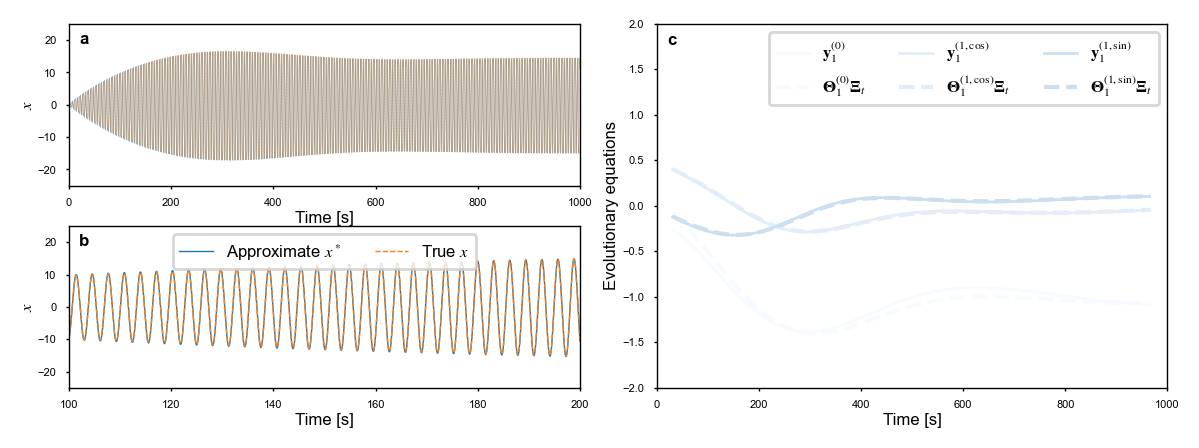

In [187]:
stp = 10
enp = 10
Omegaidxs = [0]
orders = [[0,1,2]]
Modes = 1
Xis = np.zeros([len(library)+1, Modes])
fig = plt.figure(figsize = (18/2.54,6/2.54),dpi = 200)
plt.subplots_adjust(hspace = 0.25,wspace = 0.15)
ylims = [(-0.27,0.27),(-0.0016,0.0016),(-0.007,0.007),(-0.007,0.007)]
legends = ['{(0)}','{(1,\cos)}','{(1,\sin)}']

def add_panel_label(ax, label, x=0.02, y=0.95):
    ax.text(
        x, y, label,
        transform=ax.transAxes,   # 关键：轴坐标系
        fontsize=6,
        fontweight='bold',
        va='top',
        ha='left'
    )

from matplotlib.gridspec import GridSpec

gs = GridSpec(2, 2, figure=fig)

ax = fig.add_subplot(gs[0, 0])
# 
GT = x[:,0].reshape(-1,1)
len_evo = len(np.repeat(model.evolutions[0][:,0],int(T_period*Fs)))
rebuild = np.zeros_like(GT[:len_evo])
rebuild.reshape(-1)

basis = [np.ones(len_evo), np.cos(model.frequencys[0]*t[:len_evo]), np.sin(model.frequencys[0]*t[:len_evo])]
for i in range(3):
    rebuild += (np.repeat(model.evolutions[0][:,i],int(T_period*Fs))*basis[i]).reshape(-1,1)
# axins = inset_axes(ax, width="60%", height="60%", bbox_to_anchor=(0.1, 0.75, 0.5, 0.5),  # 右侧中部
#                    bbox_transform=ax.figure.transFigure, loc='center') 
# axins.plot(t[:len_evo], rebuild, lw = 0.1,label = 'Approximate $x^*$')
# axins.plot(t, GT, lw = 0.1, label = 'True $x$')
# axins.set_xlim(t[x1],t[x2])
# axins.set_ylim(-25,25)
# axins.tick_params(direction='out',width = 0.5,length = 1)
ax.plot(t[:len_evo], rebuild, lw = 0.1,label = 'Approximate $x^*$')
ax.plot(t, GT, lw = 0.1,ls = '--', label = 'True $x$')
ax.set_xlim(0,1000)
ax.set_ylim(-25,25)
ax.set_xlabel('Time [s]')
ax.set_ylabel('$x$')
add_panel_label(ax, 'a')
ax.tick_params(direction='out',width = 0.5,length = 1)
# ax.legend()
ax = fig.add_subplot(gs[1, 0])
ax.plot(t[:len_evo], rebuild, lw = 0.5,label = 'Approximate $x^*$')
ax.plot(t, GT, lw = 0.5,ls = '--', label = 'True $x$')
ax.set_xlim(100,200)
ax.set_ylim(-25,25)
ax.set_xlabel('Time [s]')
ax.set_ylabel('$x$')
add_panel_label(ax, 'b')
ax.tick_params(direction='out',width = 0.5,length = 1)
ax.legend(ncol = 2, loc = 'upper center')


ax = fig.add_subplot(gs[:,1])
d = 0
Xi = [4-model.frequencys[0]**2, quadratic, cubic, 0, 0, damping, 0, 0, 0, 0, -Amplitude_F]

ax.set_xlabel('Time')
ax.set_xlim(0,t_periods[-1-enp])
ax.set_ylabel('Evolutionary equations')
ax.set_xlabel('Time [s]')
add_panel_label(ax, 'c',y = 0.975)
ax.tick_params(direction='out',width = 0.5,length = 1)

for i in orders[d]:
    ax.plot(t_periods[stp:-enp-1],model.dot[d][stp:-enp,i],color = colors[i],lw = 1,label = r'$\mathbf{y}_1^%s$'%legends[i])
    ax.plot(t_periods[stp:-enp-1],np.sum(model.Phi[d][stp:-enp,i,:]*Xi, axis = 1),color = colors[i],ls = '--',lw = 1.5,label = r'$\mathbf{\Theta}_1^%s\mathbf{\Xi}_t$'%legends[i])
ax.legend(ncol = 3)
ax.set_ylim(-2,2)
ax.set_xlim(0,1000)
plt.savefig("%s/theroyprove.pdf"%figsavepath,dpi = 300,transparent = True,bbox_inches="tight")

In [188]:
Xis = np.zeros([len(library)+1, Modes])
Xis[:,0] = model.Xi[0]
# Xis[0,0] += model.frequencys[0]**2
print(Xis)

[[ 2.43314820e-02]
 [ 9.54383496e-03]
 [ 9.44882223e-05]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 1.02859133e-02]
 [ 3.93977668e-05]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-5.10919978e-01]]


In [100]:
def ROM(x,t):
    dxdt = np.zeros(len(x))
    for d in range(Modes):
        dxdt[d*2] = x[d*2+1]
        for i in range(len(library)):
            dxdt[d*2+1] -= library[i](x)*Xis[i,d]
        dxdt[d*2+1] -= np.cos(Omega*t)*Xis[-1,d]
    return dxdt


x0 = np.zeros(Modes*2)
x = odeint(ROM, x0, t)

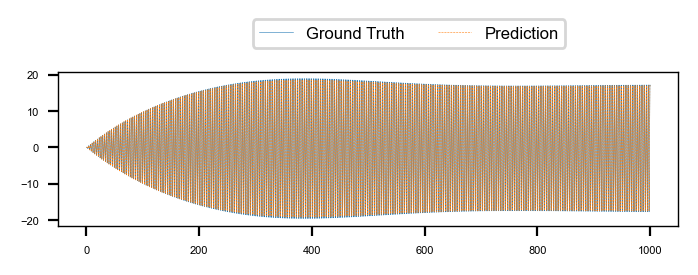

In [101]:
fig, ax = plt.subplots(Modes,1,figsize = (4,Modes*1),dpi = 200)
for i in range(Modes):
    # ax = axes[i]
    ax.plot(t, data, lw = 0.2,label = 'Ground Truth')
    ax.plot(t, x[:,i*2],lw = 0.2, ls = '--', label = 'Prediction')
    # ax.set_xlim(100,150)
    if i == 0:
        ax.legend(ncol = 2, bbox_to_anchor = (0.3,1.1))

In [ ]:
TrainFreq = Omega
TrainFrF = 

In [103]:
import util
importlib.reload(util)  # 重新载入
library_matlab = [
    'u1','u1^2','u1^3','u1^4','u1^5','v1','v1^2','v1^3','v1^4','v1^5',
    'A*c'
]
util.generate_beam_from_library(
    func_name = "Numerical_POM1_predict",
    out_path = "../Matcont_solver/models/Numerical/Numerical_POM1_predict.m",
    n_dof = Modes,
    library = library_matlab,
    coef = -1*np.array(Xis),
    tol = 1e-12
    
)



'..\\Matcont_solver\\models\\Numerical\\Numerical_POM1_predict.m'

In [108]:
Xi_truth = np.array([[omega0**2, quadratic, cubic, 0, 0, damping, 0, 0, 0, 0, -Amplitude_F]]).T
util.generate_beam_from_library(
    func_name = "Numerical_POM1_truth",
    out_path = "../Matcont_solver/models/Numerical/Numerical_POM1_Truth.m",
    n_dof = Modes,
    library = library_matlab,
    coef = -1*np.array(Xi_truth),
    tol = 1e-12
    
)

'..\\Matcont_solver\\models\\Numerical\\Numerical_POM1_Truth.m'

In [229]:
import os
import numpy as np
import matlab.engine
from tqdm.notebook import tqdm

PROJECT = r"../matcont_solver/"   # 改成你的路径
RESULTS = os.path.join(PROJECT, "results")
os.makedirs(RESULTS, exist_ok=True)

models = ['Numerical_POM1_Truth','Numerical_POM1_predict']  # 你可以放多个模型函数名
As = np.linspace(0.5,0.5,1)

omega0 = 2
Qvalue = 1000.0
X0 = [0,0,1,0]

eng = matlab.engine.start_matlab()
eng.cd(PROJECT, nargout=0)
eng.addpath(eng.genpath(PROJECT), nargout=0)
print(eng.pwd())
print(eng.which('run_frf_numerical'))

pbar = tqdm(total=len(As)*len(models))
for model in models:
    for A in As:
        for co_omega in [0.9]:
            eng.eval(f"global Global_A; Global_A = {A};", nargout=0)
            out = eng.run_frf_numerical(
                model,
                float(omega0*co_omega),
                matlab.double(X0),   # MATLAB 内部会 X0(:)
                float(Qvalue),
                nargout=1
            )
            # print(model, A, "is_empty:", eng.isempty(out))
            eng.workspace["xlcc"] = out

            savename = os.path.join(RESULTS, f"{model}_A_{A:.5f}.mat")
            eng.save(savename, "xlcc", nargout=0)
            pbar.set_description(f"{model}, A={A:.5f}")
            pbar.update(1)
eng.quit()

C:\Users\TengMa\OneDrive\文章\9. MEMS_FEM_EvLOWN\Notebook\Matcont_solver
C:\Users\TengMa\OneDrive\文章\9. MEMS_FEM_EvLOWN\Notebook\Matcont_solver\run_frf_numerical.m


  0%|          | 0/2 [00:00<?, ?it/s]

In [149]:
def xlcc2frf(xlcc,POMs):
    d1, d2 = np.shape(xlcc)
    num = len(POMs)
    orbit_len = int((d1-2-2-num*2)/(num*2+2))
    frfs_amplitude = np.zeros(d2)
    frfs_phase = np.zeros(d2)
    # force = xlcc[:,-2]
    for j in range(d2):
        orbits = np.zeros([orbit_len,num])
        
        cos = xlcc[num*2+1:-((num+1)*2)-2+num*2+1:(num+1)*2,j]
        sin = xlcc[num*2:-((num+1)*2)-2+num*2:(num+1)*2,j]
        # print(len(cos),len(sin))
        theta = np.linspace(0, 2*np.pi, len(cos), endpoint=False)
        for i in range(num):
            orbits[:,i] = xlcc[i*2:-((num+1)*2)-2+i*2:(num+1)*2, j]
            
        orbit_poms = np.sum(orbits * POMs, axis = 1).reshape(-1)

        
        frfs_amplitude[j] = (np.max(orbit_poms) - np.min(orbit_poms))/2
        A = 2 * np.trapz(orbit_poms*cos, theta)
        B = 2 * np.trapz(orbit_poms*sin, theta)
        frfs_phase[j] = np.arctan2(B, A)
        
    return xlcc[-1,:-1], frfs_amplitude[:-1], frfs_phase[:-1]

C:\Users\TengMa\AppData\Local\Temp\ipykernel_31860\3615076229.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap("Blues")


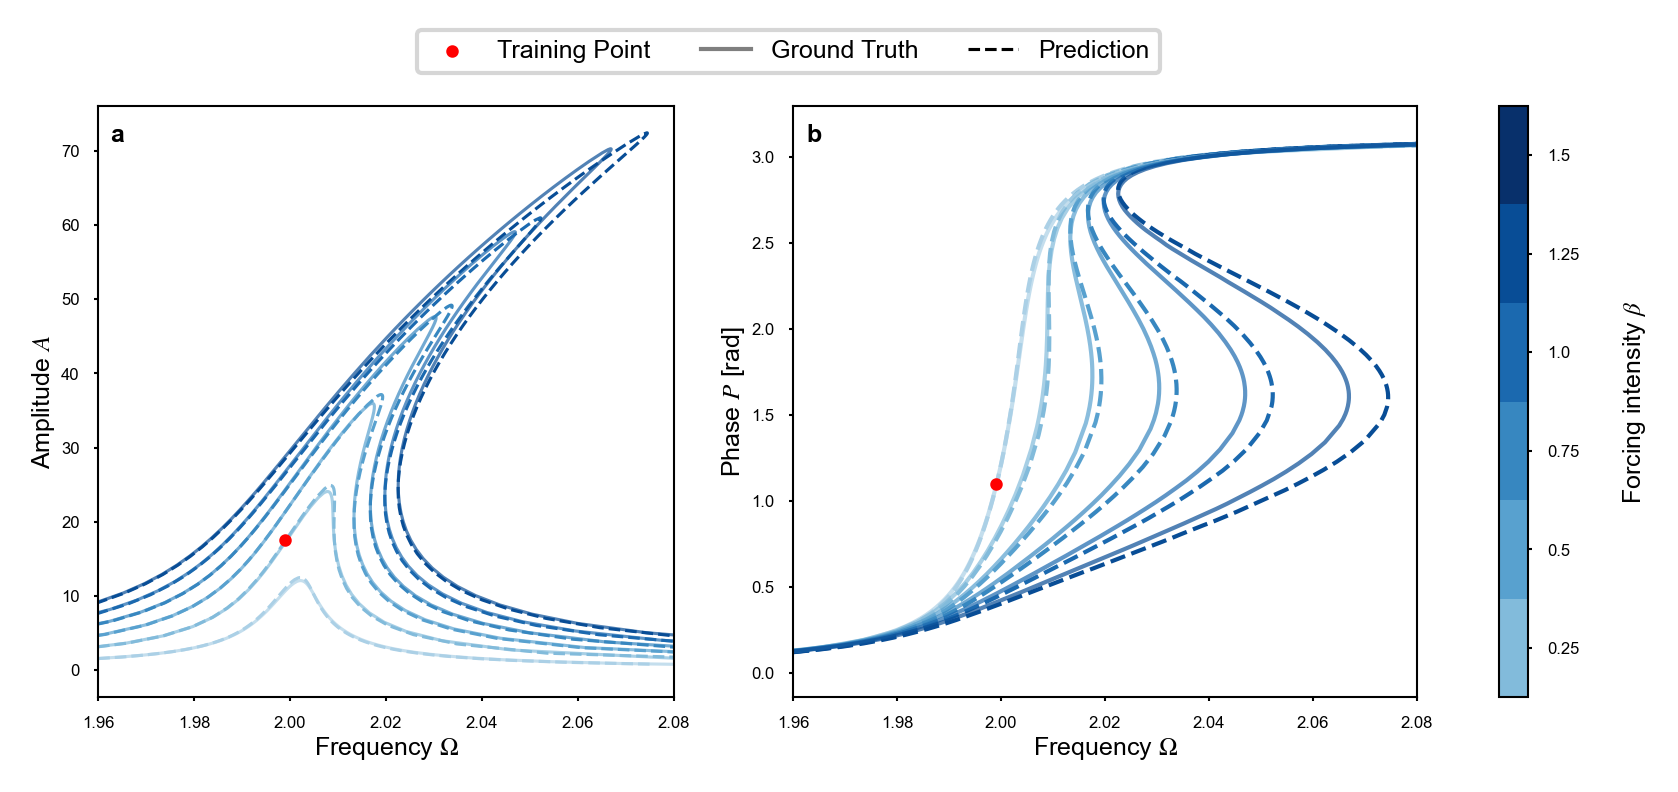

In [257]:
fig, axes = plt.subplots(1,2,figsize = (18/2.54, 6.5/2.54),width_ratios=[0.48,0.52],dpi = 300)
cm_number = 10
cm = plt.cm.get_cmap("Blues")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
As = np.linspace(0.5,3,6)
lss = ['--','-']
alphas = [1,0.7]
for j in range(len(models)):
    ls = lss[j]
    alpha = alphas[j]
    model = models[j]
    for i in range(len(As)):
        A = As[i]
        # print(A)
        xlcc = scipy.io.loadmat('%s/results/%s_A_%.5f'%(PROJECT,model,A))['xlcc']
        freq, FAs, FPs = xlcc2frf(xlcc,[1])
        axes[0].plot(freq[3:-3], FAs[3:-3], color =  colors[i+3],lw = 0.75,ls = ls, alpha = alpha)
        axes[1].plot(freq, FPs, color =  colors[i+3], lw = 1,ls = ls, alpha = alpha)
axes[0].set_xlim(1.96,2.08)
axes[1].set_xlim(1.96,2.08)
add_panel_label(axes[0], 'a',y=0.97)
add_panel_label(axes[1], 'b',y=0.97)
axes[0].set_xlabel("Frequency $\Omega$")
axes[0].set_ylabel("Amplitude $A$")
axes[1].set_xlabel("Frequency $\Omega$")
axes[1].set_ylabel("Phase $P$ [rad]")
axes[0].scatter([Omega],[17.5], color = 'red', s = 4,zorder = 100,label = 'Training Point')
axes[0].plot([0,0],[1,1],ls = '-',alpha = 0.5,lw = 1,color = 'black',label = 'Ground Truth')
axes[0].plot([0,0],[1,1],ls = '--',alpha = 1,lw = 0.75,color = 'black',label = 'Prediction')
axes[0].legend(ncol = 3,loc = 'upper center',bbox_to_anchor = (1.2,1.15))
axes[1].scatter([Omega],[1.1], color = 'red', s = 4,zorder = 100)
axes[0].tick_params(direction='out',width = 0.5,length = 1)
axes[1].tick_params(direction='out',width = 0.5,length = 1)
cmap_discrete = mpl.colors.ListedColormap(colors[4:])
bounds = list(range(4, cm_number+1))
norm = mpl.colors.BoundaryNorm(bounds, cmap_discrete.N)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_discrete)
sm.set_array([])
tick_positions = [4.5, 5.5, 6.5, 7.5, 8.5, 9.5]
# 你可以根据实际意义随意改 label 文本
tick_labels = As/2
cbar = fig.colorbar(sm, ax=axes, ticks=tick_positions)
cbar.ax.set_yticklabels(tick_labels)
cbar.set_label(r"Forcing intensity $\beta$",labelpad = 10)
cbar.ax.minorticks_off()
cbar.ax.tick_params(direction='out',width = 0.5,length = 1)
plt.savefig("%s/FRFpredict.pdf"%figsavepath,dpi = 300,transparent = True,bbox_inches="tight")

In [224]:
A = 0.5
model = models[0]
xlcc = scipy.io.loadmat('%s/results/%s_A_%.5f'%(PROJECT,model,A))['xlcc']
freq, FAs, FPs = xlcc2frf(xlcc,[1])

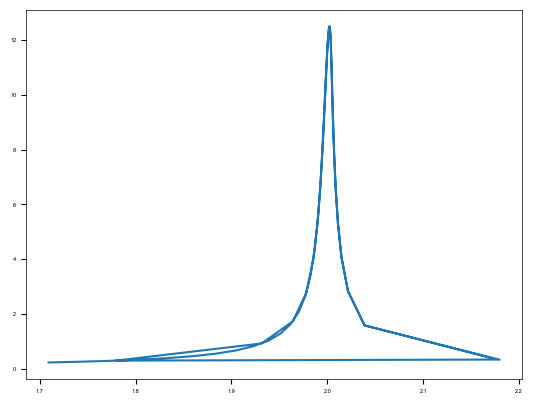

In [225]:
plt.plot(freq,FAs)

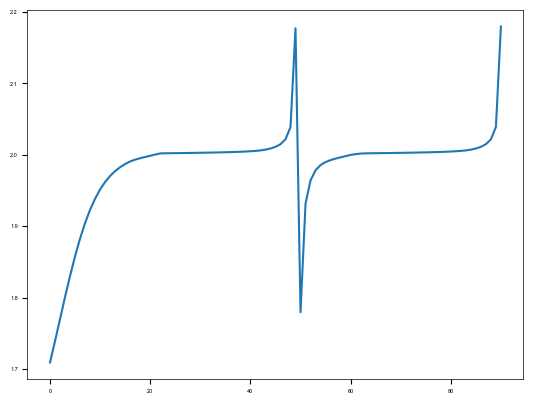

In [226]:
plt.plot(freq)